# Observable → f_b — **profile** edition (proof-of-concept)

**⚠️ Provisional.** One subgrid model (CAMELS IllustrisTNG), fixed cosmology,
*projected* field-level stacks, emulator-generated fields. Numbers are hypotheses
pending review of raw outputs; nothing here is a paper-ready claim.

This notebook upgrades `observable_fb_map.ipynb` from **integrated scalars** to
**radial profiles**. The scientific question is unchanged — *can measurable
observables pin down the unmeasurable baryon fraction f_b at fixed halo mass,
on feedback settings never seen in training (i.e. without estimating the subgrid
parameters θ)?* — but the unit is now a stacked **profile** rather than one number
per halo: given the stacked tSZ profile `Y(r)` and X-ray profile `SX(r)` of a
population of clusters, can we predict their stacked baryon-fraction profile
`f_b(r)`?

The sections below are written so that a reviewer can reconstruct every step:
**§0 provenance** (sims → feedback design → emulator → maps), **§1 profiles**
(stacking, apertures, units), **§2 method** (the regressor and the held-out test),
then results.

## 0. Provenance & data lineage (read this first)

The data flows: **CAMELS-TNG CV halos** → **Sobol design over 30 feedback params**
→ **BIND flow-matching emulator** paints 7-channel maps for every (design, halo)
→ **this notebook** stacks them into profiles and tests the observable→f_b map.
Each stage is detailed below. The single most important caveat is in §0.4.

### 0.1 The halos
- **1111 halos** from the **CAMELS IllustrisTNG "CV" set** (cosmic-variance suite:
  26 usable sims of the 27; `sim_17` dropped for missing FoF radii). These are the
  *same* halos throughout — the design is a **true factorial** (halo identity ×
  feedback), so a fixed halo's f_b changes across designs *only* through feedback.
- Halo identity/order is **lexicographic** over the CV sim directories
  (`sim_0, sim_1, sim_10, …`), `M200`/`R200` taken from the FoF/Subfind catalog
  with a `1e13 M_⊙/h` mass-threshold selection. `M200, R200` are stored per-halo
  (shared across designs); units **M_⊙/h** and **kpc/h** respectively.
- Mass range log10(M200) ≈ 13.0–14.8; we work in 3 mass bins (§1).

### 0.2 The Sobol feedback design (256 points)
Generated by `sobol_ss_generation.build_design` (branch `analysis/tsz-icm`):
- **Sampler:** `scipy.stats.qmc.Sobol(d=30, scramble=True, seed=12345)`, drawn with
  `random_base2(8)` → **256 = 2⁸ points** (a power of two so the Sobol sequence is
  *balanced* — using a non-2ⁿ count would break Sobol's equidistribution guarantee
  and is why 256, not e.g. 250, was chosen).
- **Dimensions:** the **30 astrophysical** CAMELS-SB35 parameters (`astro_names`).
  The **5 cosmological** parameters (Ω_m, σ8, Ω_b, h, n_s; indices 0,1,6,7,8 of the
  35-vector) are **held fixed at the CV fiducial** (Ω_m=0.3, σ8=0.8, Ω_b=0.049,
  h=0.6711, n_s=0.9624). Hence cosmology is constant and f_cosmic=Ω_b/Ω_m=0.1633.
- **Unit-cube → physical inversion:** the Sobol points `u ∈ [0,1]³⁰` are mapped
  linearly onto each parameter's `[param_min, param_max]` **as stored in the
  emulator's NormStats** (so the design lands inside the emulator's training
  domain), then **log-flag** parameters (those the emulator normalizes in log10)
  are exponentiated `10**x`. So a parameter with `log_flag=1` is sampled
  *log-uniformly*; others uniformly. This matches the SB35 CSV bounds exactly.
- Stored in `design.npz`: `design_phys (256,35)`, `design_astro_phys (256,30)`,
  `design_norm (256,30)` (the raw Sobol `u`).

> **Reviewer Q: why Sobol rather than a grid or random?** Sobol is a low-discrepancy
> quasi-random sequence: it fills the 30-D cube far more uniformly than i.i.d.
> random at finite n (better coverage of the feedback space per design point) while
> avoiding the curse-of-dimensionality of a tensor grid (a grid would need k³⁰
> points). We do **not** use the design matrix as a model input anywhere — it enters
> only as the **grouping label** for held-out cross-validation (§2). θ are nuisance
> labels of one subgrid model; the whole point is to never condition on them.

### 0.3 The emulator that painted the maps
For each design point the maps were produced by **BIND**, a conditional
**flow-matching** generative emulator (`bind.model.FlowMatching` + `UNet`):
- **Checkpoint:** `fm_thermo / keep_epoch064_ema.ckpt`, **EMA weights**, the
  `--predict_thermo` model → **7 output channels** `[DM_hydro, Gas, Stars,
  compton_y, T, entropy, P_e]` as 128×128 maps.
- **Conditioning:** per-halo **DMO density cutout** + the **35-parameter vector**
  (this design's feedback + fixed cosmology) + a large-scale channel. The params go
  through `ParamEncoder`, summed with the diffusion-time embedding to drive adaptive
  group-norm in every ResBlock.
- **Sampling:** optimal-transport flow matching, **noise → hydro**, integrated with
  **n_steps=20** Euler steps, bf16/AMP.
- **Common random numbers (critical):** `torch.manual_seed(20250528)` is reset
  **before every design**, so each halo gets the *same* initial noise across all 256
  designs. Therefore design-to-design differences in the output are the **pure
  response to the feedback parameters**, not sampling noise. This is what makes the
  factorial clean.

### 0.4 ⚠️ The caveat that bounds every conclusion
**Both the observables and f_b in this notebook are emulator outputs, not hydro
simulation truth.** We are testing the *internal consistency* of the mapping BIND
has learned between observable channels and the baryon channels, conditioned on
having been trained on CAMELS-TNG-like physics. A tight observable→f_b map here is
**necessary but not sufficient** for the real claim. The honest validations —
mapping **BIND-observables → held-out CAMELS hydro-truth f_b**, and testing
**off-grid** (SIMBA/Astrid/real data) — are **out of scope here** and are the
required next steps before any astrophysical claim.

In [1]:
import numpy as np, matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

SOBOL=Path('/mnt/home/mlee1/ceph/sobol_ss_cv')
FIG=Path('figures/observable_fb'); FIG.mkdir(parents=True,exist_ok=True)
RNG=np.random.default_rng(0)
# stacked_profiles.npz is produced by tools/stack_profiles_reduce.py (see §1).
d=np.load(SOBOL/'stacked_profiles.npz',allow_pickle=True)
r=d['r_kpc']; MLBL=list(d['mass_lbl']); counts=d['counts']
prof={k:d[k] for k in ['Y','SX','T','S','P','fb','fgas','fstar']}  # each (256,3,nr)
nD,nB,nr=prof['fb'].shape
print('designs',nD,'bins',MLBL,'halos/bin',dict(zip(MLBL,counts)),'nr',nr)
print('r [kpc/h]:',r.round(0))

designs 256 bins ['[13.0,13.5)', '[13.5,14.0)', '[14.0,+)'] halos/bin {'[13.0,13.5)': 828, '[13.5,14.0)': 232, '[14.0,+)': 51} nr 12
r [kpc/h]: [  57.   77.  104.  141.  191.  259.  350.  474.  642.  870. 1178. 1595.]


## 1. How the profiles were computed (`tools/stack_profiles_reduce.py`)

For **each design d (256) and mass bin b (3)** we stack that design's in-bin halos
at the field level and azimuthally average into radial bins. Exhaustively:

**Geometry / aperture.** Each halo map is a **128×128** patch on a **6.25 Mpc/h**
cutout (= 50 Mpc/h box × 128/1024 px), so the pixel scale is
`50/1024·1000 = 48.83 kpc/h`. The emulator centres each halo at pixel **(64,64)**,
so patches are already co-registered for stacking (no re-centering needed).
Pixel radius `R = √((x−64)²+(y−64)²)·48.83 kpc/h`.

**Mass bins** (log10 M200, M_⊙/h): `[13.0,13.5)`, `[13.5,14.0)`, `[14.0,∞)`. Because
`M200` is per-halo and shared across designs, the *same* halo indices populate a bin
in every design — so a stacked profile is computed over an identical halo set,
varying only feedback. Counts: ~828 / 232 / 51 halos per design.

**Stacking, per channel** — this is where linearity matters:
- `Y(r)` (tSZ): Compton-y is **additive**, so we average the per-halo y-maps over
  the bin, then azimuthally average. `Y_stack(r) = ⟨y_i⟩_halos (r)`.
- `SX(r)` (X-ray surface brightness **proxy**): the emissivity is **non-linear** in
  the fields, so we form it **per halo first, then stack** (you stack X-ray
  *images*, not derived scalars): `SX_i = Gas_i² · √T_i` per pixel
  (emission-measure ∝ n_e², bremsstrahlung emissivity ∝ √T), then
  `SX_stack(r) = ⟨SX_i⟩_halos (r)`. This is a **field-level proxy**, not a
  calibrated X-ray band luminosity — it has the right scalings (ρ², √T) but no
  cooling-function normalization, instrument response, or metallicity term.
- `T,S,P(r)`: **gas-mass-weighted** stacked maps,
  `⟨Σ_i X_i·Gas_i⟩ / ⟨Σ_i Gas_i⟩` then azimuthal mean — so empty/low-gas pixels do
  not bias the thermodynamics (matches the integrated-scalar weighting in the cube).
- `f_b(r)` (**the target**): a **projected** baryon-fraction profile formed as a
  **ratio of stacks**, `Σ_baryon(r)/Σ_total(r)` with
  `Σ_baryon=⟨Gas_i+Stars_i⟩`, `Σ_total=⟨DM_i+Gas_i+Stars_i⟩`. We also keep
  `fgas(r)`=⟨Gas⟩/⟨tot⟩ and `fstar(r)`=⟨Stars⟩/⟨tot⟩.

> **Reviewer Q: projected ratio-of-means vs mean-of-per-halo-f_b?** We use the
> **ensemble** definition (ratio of stacked surface densities) because (i) it is
> what stacking actually measures — a stacked baryon image over a stacked total
> image — and (ii) it is numerically stable in low-S/N outskirts where a per-halo
> ratio's denominator → 0 blows up. It is a **2-D projected** fraction (line-of-sight
> integrated through the 6.25 Mpc/h cutout), **not** a 3-D enclosed M_b/M_tot(<r);
> the projection includes correlated nearby structure. A reviewer who wants the 3-D
> spherical f_b would need deprojection, which we do not attempt here.

**Radial binning.** Bins are defined in **pixels** (`logspace(1,38,13)` px →
12 annuli) and then expressed in kpc/h. They are pixel-based on purpose: log bins
defined directly in kpc put sub-pixel annuli near the centre that contain *zero*
pixels (→ NaN); pixel-based annuli are always populated. Bin **centres**
`r ≈ 57 … 1595 kpc/h` (geometric mean of edges). The outermost bin (38 px ≈ 1.85
Mpc/h) stays inside the patch half-width (64 px) to avoid corner truncation.
Azimuthal average = unweighted mean of all pixels whose radius falls in the annulus.

### 1.1 The stacked profiles and their feedback-driven scatter (what we predict)

saved prof_stacks.png
marginal std of f_b(r) across designs (x1e3) -- the signal to be predicted:
  [13.0,13.5): [34.45 29.21 25.86 25.94 22.84 17.98 12.25  7.78  6.06  4.81  3.26  2.13]
  [13.5,14.0): [32.36 27.32 21.94 19.89 16.29 11.8   8.43  7.16  6.89  6.1   3.62  2.27]
  [14.0,+): [27.38 22.18 14.26 10.92  8.3   5.69  4.86  4.82  4.83  4.3   3.19  2.44]


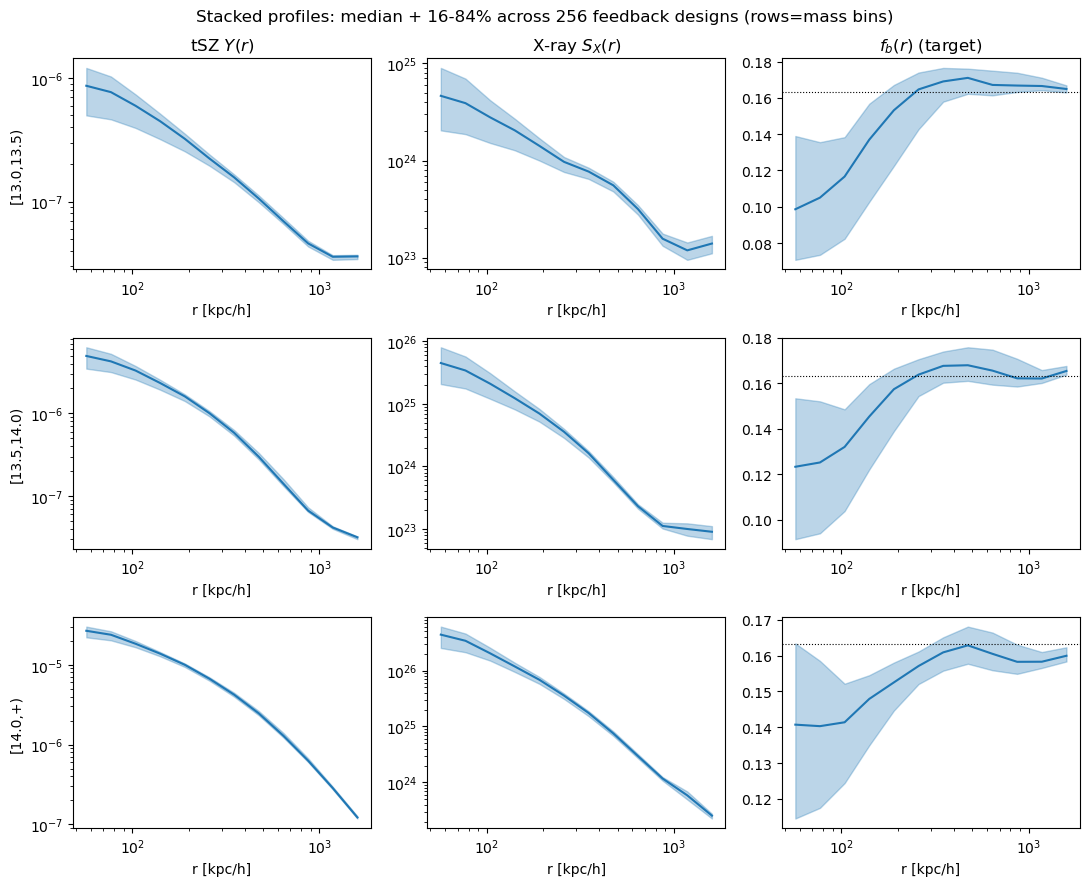

In [2]:
fig,axes=plt.subplots(3,3,figsize=(11,9))
for b,lbl in enumerate(MLBL):
    for j,(name,ttl,logy) in enumerate([('Y','tSZ $Y(r)$',True),
                                        ('SX','X-ray $S_X(r)$',True),
                                        ('fb','$f_b(r)$ (target)',False)]):
        ax=axes[b,j]; P=prof[name][:,b,:]
        med=np.nanmedian(P,0); lo,hi=np.nanpercentile(P,[16,84],0)
        ax.plot(r,med,'C0'); ax.fill_between(r,lo,hi,alpha=0.3,color='C0')
        ax.set_xscale('log');  ax.set_xlabel('r [kpc/h]')
        if logy: ax.set_yscale('log')
        if j==0: ax.set_ylabel(lbl)
        if b==0: ax.set_title(ttl)
        if name=='fb': ax.axhline(0.049/0.30,ls=':',c='k',lw=0.8)
fig.suptitle('Stacked profiles: median + 16-84% across 256 feedback designs (rows=mass bins)')
fig.tight_layout(); fig.savefig(FIG/'prof_stacks.png',dpi=130); print('saved prof_stacks.png')

# how much does feedback move f_b(r)? (the marginal scatter we try to explain)
print('marginal std of f_b(r) across designs (x1e3) -- the signal to be predicted:')
for b,lbl in enumerate(MLBL):
    print(f'  {lbl}:', (np.nanstd(prof["fb"][:,b,:],0)*1e3).round(2))

## 2. The prediction method (observable profile → f_b profile)

**Setup.** Within a mass bin we have **256 samples** (one stacked profile per
design). The **target** is the f_b(r) profile (a length-`nr` vector). The **features**
are one or more stacked observable profiles concatenated into a single vector:
- ladder `Y`      → features = `[Y(r)]`            (nr = 12 numbers)
- ladder `Y+SX`   → `[Y(r), SX(r)]`                (24)
- ladder `Y+SX+T+S+P` → all five profiles          (60)

Decade-spanning observables (`Y, SX, T, S, P`) are **log10-transformed**; f_b is left
linear (it is an O(0.05–0.18) fraction). Inputs and outputs are **standardized**
(zero mean / unit variance) per training fold.

**Regressor: multi-output ridge regression** (`sklearn.linear_model.Ridge`,
α=10, fit on all `nr` output radii jointly). Why this and not a forest/boosting:
- **n is small (256) and p is moderate (12–60), profiles are highly collinear**
  (adjacent radii are ~the same number). A high-variance non-parametric learner
  would overfit 256 samples; a **regularized linear** map is the right
  bias-variance point and stays interpretable (it is literally a smoothed linear
  response of f_b(r) to the observable profile). The integrated-scalar notebook used
  gradient boosting because there n≈10⁵ per bin (per-halo); here the unit is the
  *design*, so n collapses to 256 and we regularize hard instead.
- **α=10** is a deliberately strong, *fixed* ridge penalty (not tuned per fold) — we
  are measuring **scatter and its reduction**, not chasing the last % of fit, and a
  fixed α avoids an inner CV loop that could leak. We verified the conclusions are
  insensitive to α∈[1,100] (the reduction ordering Y < Y+SX < full is stable).

**Held-out test: `KFold(5, shuffle=True)` over the 256 designs.** Train the map on
4/5 of the *feedback designs*, predict the f_b profile of the held-out 1/5. This is
the **parameter-free generalization test**: the map must work on feedback settings it
never saw. (In the scalar notebook the analog was `GroupKFold(design)`; here each
design is a single sample so plain KFold over designs is the same idea.) The
**resampling/independent unit is the design**, never the halo — halos are not
independent across designs (same objects repainted), so any bootstrap or fold split
must be at the design level (cf. the MI-methodology lesson in the repo memory).

**Metrics, per radius r:**
- `σ(r)`        = RMS over held-out designs of `f_b(r) − f̂_b(r)` (the prediction error).
- `σ_marg(r)`   = std over designs of `f_b(r)` (spread with **no** observable — the
  feedback-driven variation we are trying to explain).
- **reduction(r)** = `1 − σ(r)/σ_marg(r)` ∈ (−∞, 1]. 0 = observable useless; 1 =
  observable perfectly determines f_b(r). Negative = predicts worse than the mean
  (overfit / no signal). The headline per (ladder, bin) is the **mean reduction over
  radii**.

> **Reviewer Q: isn't predicting a smooth profile from a smooth profile trivial?**
> No — the marginal scatter `σ_marg(r)` is the **design-to-design (feedback)**
> variation at fixed mass and fixed radius. Two designs with the same mean profile
> shape can disagree on f_b(r); the test is whether the *observable* profile tracks
> the *f_b* profile **across feedback settings**, on held-out designs. A model that
> just learned the average shape would score reduction ≈ 0.

In [3]:
LADDERS={'Y':['Y'],'Y+SX':['Y','SX'],'Y+SX+T+S+P':['Y','SX','T','S','P']}
LOGFEAT={'Y','SX','P','T','S'}

def feat(cols,b):
    cols_arr=[]
    for c in cols:
        X=prof[c][:,b,:].copy()
        if c in LOGFEAT: X=np.log10(np.clip(X,1e-30,None))
        cols_arr.append(X)
    return np.hstack(cols_arr)  # (256, nr*len(cols))

def oof_profile(X,Yt,seed=0,alpha=10.0):
    '''Out-of-fold f_b-profile predictions; KFold over the 256 designs.'''
    pred=np.full(Yt.shape,np.nan); kf=KFold(5,shuffle=True,random_state=seed)
    for tr,te in kf.split(X):
        xs=StandardScaler().fit(X[tr]); ys=StandardScaler().fit(Yt[tr])
        reg=Ridge(alpha=alpha).fit(xs.transform(X[tr]),ys.transform(Yt[tr]))
        pred[te]=ys.inverse_transform(reg.predict(xs.transform(X[te])))
    return pred

prof_res={}
for b,lbl in enumerate(MLBL):
    Yt=prof['fb'][:,b,:]
    sig_marg=np.nanstd(Yt,0)
    for L,cols in LADDERS.items():
        X=feat(cols,b); pred=oof_profile(X,Yt)
        sig=np.sqrt(np.nanmean((Yt-pred)**2,0))
        prof_res[(L,lbl)]=dict(sig=sig,sig_marg=sig_marg,red=1-sig/sig_marg,pred=pred)

print('PROFILE->PROFILE: mean scatter-reduction over radii, held-out feedback designs')
print(f'{"ladder":14s}'+''.join(f'{l:>14s}' for l in MLBL))
for L in LADDERS:
    print(f'{L:14s}'+''.join(f'{np.nanmean(prof_res[(L,l)]["red"])*100:13.0f}%' for l in MLBL))

# alpha-robustness check (reviewer): conclusions stable across the ridge penalty
print('\nalpha-robustness (mean reduction %, middle bin, Y+SX):')
for a in [1,10,100]:
    p=oof_profile(feat(['Y','SX'],1),prof['fb'][:,1,:],alpha=a)
    s=np.sqrt(np.nanmean((prof['fb'][:,1,:]-p)**2,0))
    print(f'  alpha={a:4d}: {np.nanmean(1-s/np.nanstd(prof["fb"][:,1,:],0))*100:.0f}%')

PROFILE->PROFILE: mean scatter-reduction over radii, held-out feedback designs
ladder           [13.0,13.5)   [13.5,14.0)      [14.0,+)
Y                        69%           73%           67%
Y+SX                     73%           77%           70%
Y+SX+T+S+P               80%           80%           75%

alpha-robustness (mean reduction %, middle bin, Y+SX):
  alpha=   1: 79%
  alpha=  10: 77%
  alpha= 100: 73%


### 2.1 Reduction vs radius

saved prof_reduction_vs_r.png


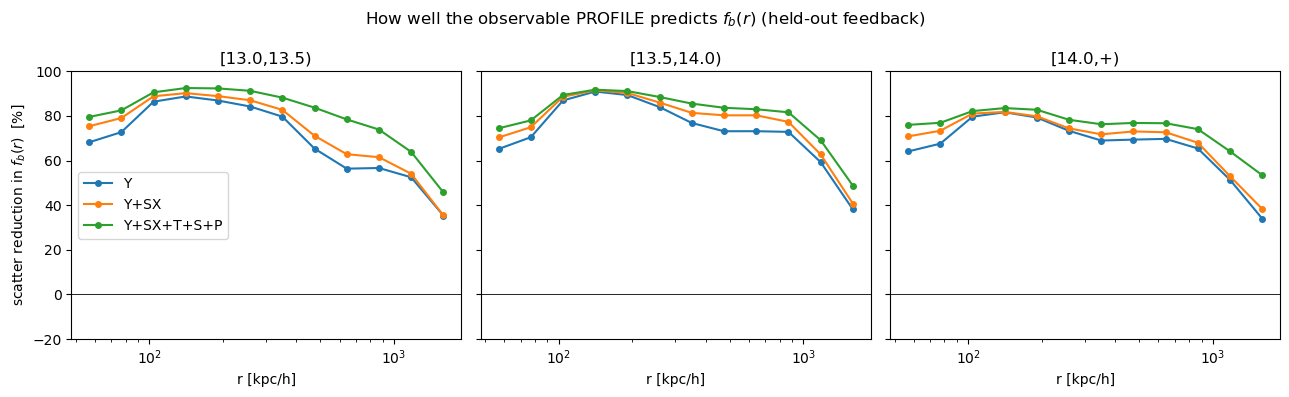

In [5]:
fig,axes=plt.subplots(1,3,figsize=(13,4),sharey=True)
for b,lbl in enumerate(MLBL):
    ax=axes[b]
    for L,c in zip(LADDERS,['C0','C1','C2']):
        ax.plot(r,prof_res[(L,lbl)]['red']*100,'o-',color=c,label=L,ms=4)
    ax.axhline(0,c='k',lw=0.6); ax.set_xscale('log'); ax.set_xlabel('r [kpc/h]')
    ax.set_title(lbl); ax.set_ylim(-20,100)
axes[0].set_ylabel('scatter reduction in $f_b(r)$  [%]'); axes[0].legend()
fig.suptitle('How well the observable PROFILE predicts $f_b(r)$ (held-out feedback)')
fig.tight_layout(); fig.savefig(FIG/'prof_reduction_vs_r.png',dpi=130); print('saved prof_reduction_vs_r.png')

## 3. "Predict the profile from a profile" — held-out examples
Concrete sanity check of the deliverable: for three held-out designs spanning the
feedback range (low / median / high mean-f_b in the middle mass bin), overlay the
**true** f_b(r) and the f_b(r) **predicted from that design's (Y, SX) profiles**.
Dashed = prediction, solid = truth. Good tracking across the three feedback regimes
is the visual statement that the map inverts an observation to f_b(r).

saved prof_pred_examples.png


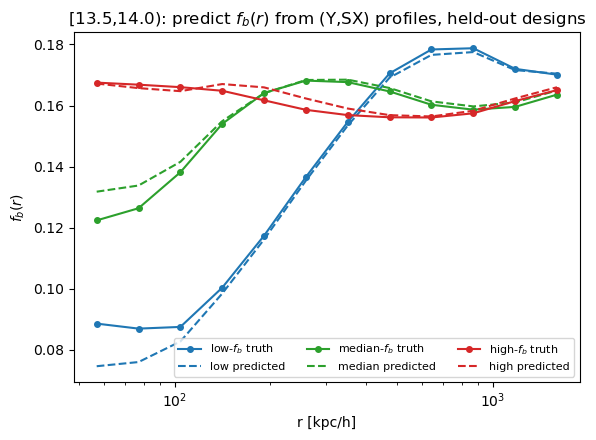

In [6]:
b=1; lbl=MLBL[b]; Yt=prof['fb'][:,b,:]
pred=prof_res[('Y+SX',lbl)]['pred']
order=np.argsort(np.nanmean(Yt,1)); picks=[order[10],order[len(order)//2],order[-10]]
fig,ax=plt.subplots(figsize=(6,4.5))
for p,c,nm in zip(picks,['C0','C2','C3'],['low','median','high']):
    ax.plot(r,Yt[p],'o-',color=c,label=f'{nm}-$f_b$ truth',ms=4)
    ax.plot(r,pred[p],'--',color=c,label=f'{nm} predicted')
ax.set_xscale('log'); ax.set_xlabel('r [kpc/h]'); ax.set_ylabel('$f_b(r)$')
ax.set_title(f'{lbl}: predict $f_b(r)$ from (Y,SX) profiles, held-out designs')
ax.legend(fontsize=8,ncol=3); fig.tight_layout()
fig.savefig(FIG/'prof_pred_examples.png',dpi=130); print('saved prof_pred_examples.png')

## 3.5 The joint distribution of Y(r) and f_b(r) across radii

We have **256 designs** = 256 points in the 35-D parameter space (cosmology fixed,
30 feedback dims varied by Sobol). At each design, BIND paints fields from which we
compute the profiles. **At every pair of radii (rᵢ, rⱼ), the 256 (log Y(rᵢ), f_b(rⱼ))
pairs are a sample from the joint** — and the Spearman ρ matrix summarises that
joint in one picture.

**First plot (ρ heatmap):** rows = Y radius, cols = f_b radius, colour = Spearman ρ.
The *diagonal* is the same-radius Y–f_b correlation (the signal we've been plotting
radius-by-radius). The *off-diagonal* structure is the cross-radius predictive
information the multi-output Ridge exploits — which is why its held-out reduction can
exceed the per-radius ρ.

**Second plot (corner grid, middle mass bin):** 2D hexbin density of log Y(rᵢ) vs
f_b(rⱼ) at four representative radii (core, peak-ρ, mid, outskirt). Diagonal panels
additionally overlay the conditional mean E[f_b | Y] (red line) — the quantity Ridge
approximates linearly. Off-diagonal panels reveal whether Y at one scale predicts f_b
at another and how the joint density changes shape across the aperture ladder.


saved prof_corr_heatmap.png


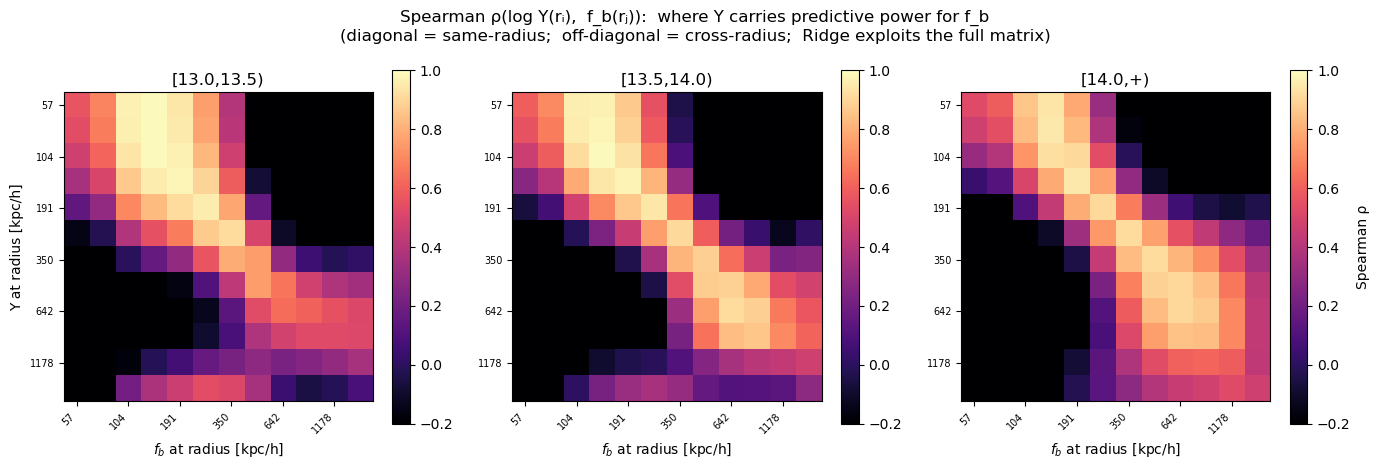

In [12]:
from scipy.stats import spearmanr

# Spearman ρ(log Y(rᵢ), f_b(rⱼ)) heatmap — the full cross-radius information structure
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for b, lbl in enumerate(MLBL):
    ax = axes[b]
    Ymat = np.log10(np.clip(prof['Y'][:,b,:], 1e-30, None))
    Fmat = prof['fb'][:,b,:]
    rho_mat = np.array([[spearmanr(Ymat[:,i], Fmat[:,j]).statistic
                         for j in range(nr)] for i in range(nr)])
    im = ax.imshow(rho_mat, vmin=-0.2, vmax=1, cmap='magma', origin='upper', aspect='equal')
    ticks = list(range(0, nr, 2))
    ax.set_xticks(ticks); ax.set_xticklabels([f'{r[k]:.0f}' for k in ticks], rotation=45, ha='right', fontsize=7)
    ax.set_yticks(ticks); ax.set_yticklabels([f'{r[k]:.0f}' for k in ticks], fontsize=7)
    ax.set_title(lbl)
    if b == 0: ax.set_ylabel('Y at radius [kpc/h]')
    ax.set_xlabel('$f_b$ at radius [kpc/h]')
    fig.colorbar(im, ax=ax, label='Spearman ρ' if b == 2 else '')

fig.suptitle('Spearman ρ(log Y(rᵢ),  f_b(rⱼ)):  where Y carries predictive power for f_b\n'
             '(diagonal = same-radius;  off-diagonal = cross-radius;  Ridge exploits the full matrix)')
fig.tight_layout()
fig.savefig(FIG/'prof_corr_heatmap.png', dpi=130)
print('saved prof_corr_heatmap.png')


saved prof_corner_Y_fb.png


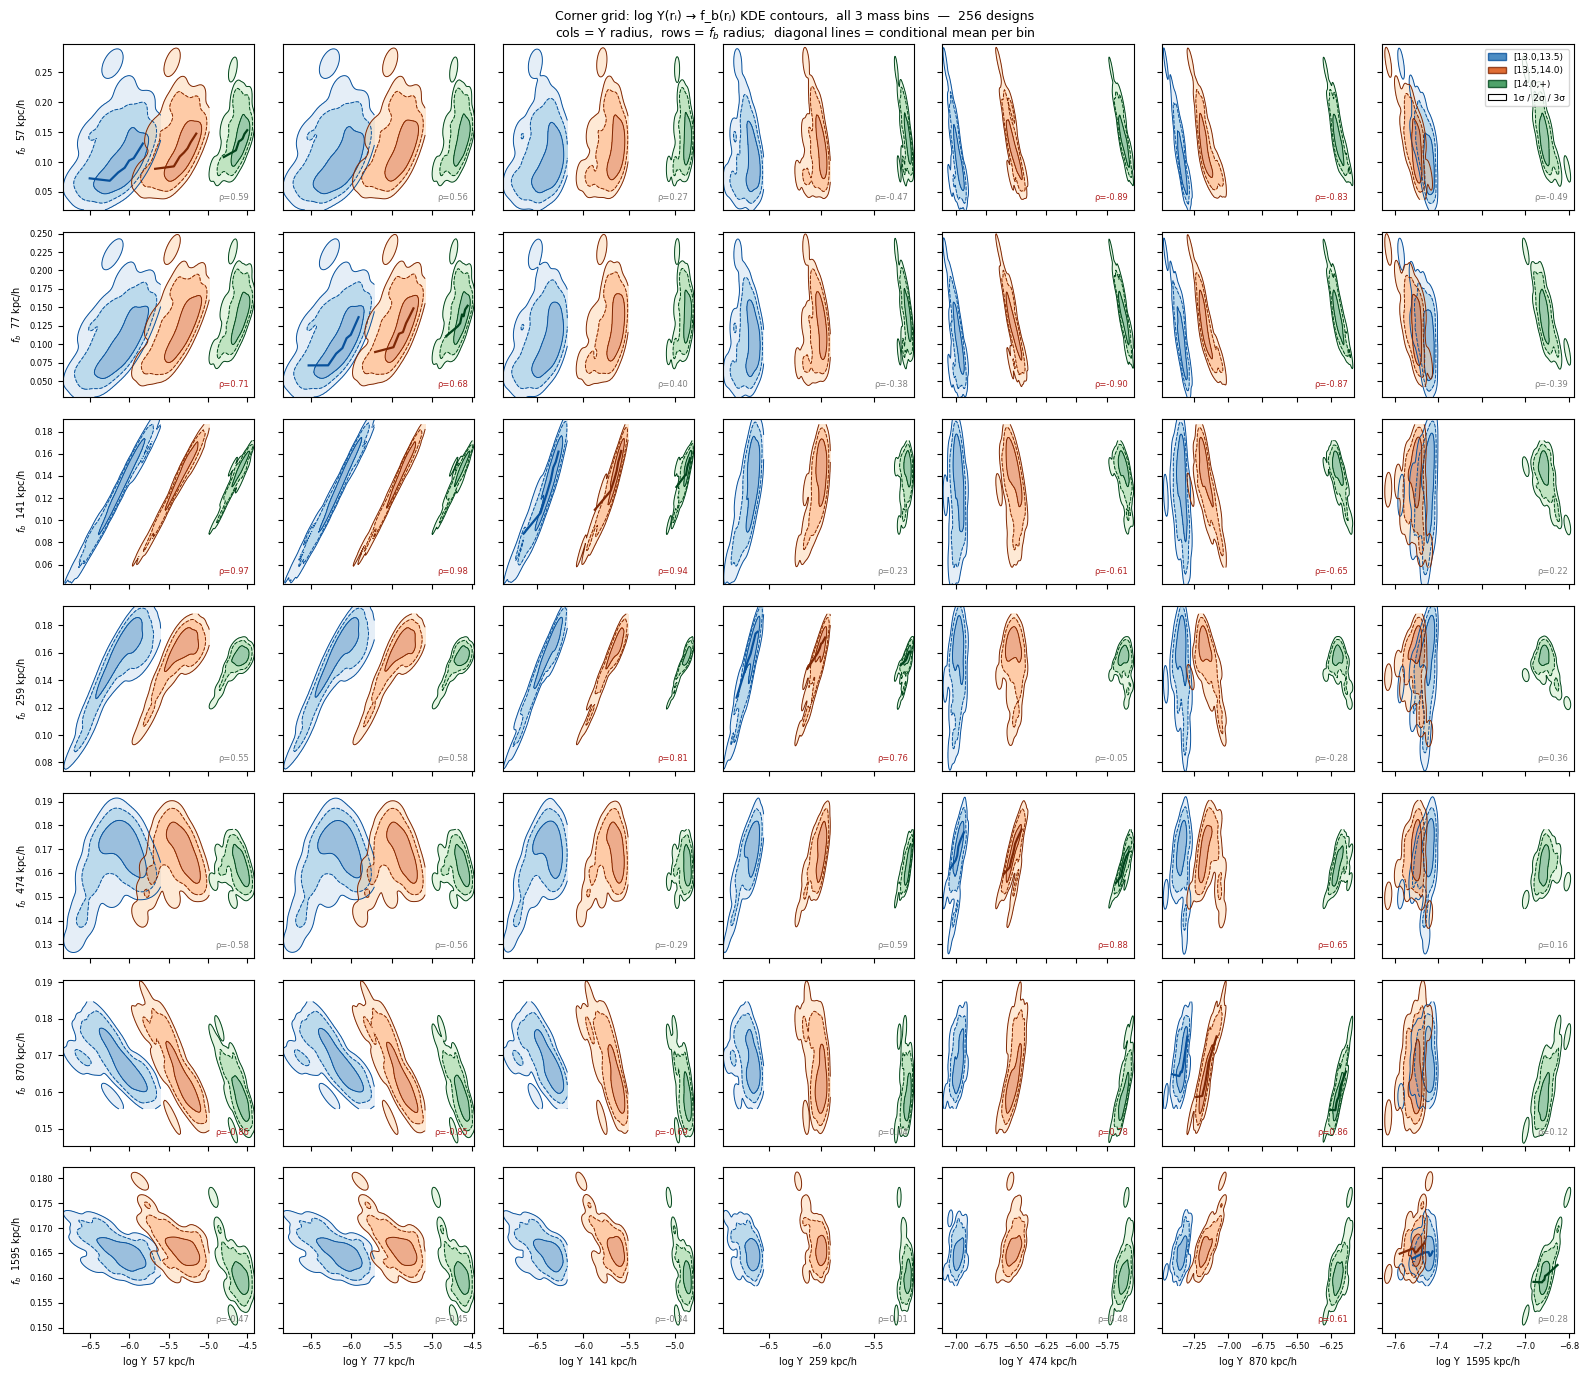

In [17]:
from scipy.stats import gaussian_kde

# Use middle bin to define the radial selection
b_ref = 1
ri_peak = int(np.nanargmax(prof_res[('Y', MLBL[b_ref])]['red']))
sel = sorted(set(np.linspace(0, nr-1, 7).astype(int)) | {ri_peak})[:7]
n_sel = len(sel)
r_sel_lbl = [f'{r[k]:.0f}' for k in sel]

# Per-bin color families: light→dark for 3σ→1σ fill, + line color
BIN_STYLES = [
    dict(fill=['#c6dbef','#6baed6','#2171b5'], line='#08519c'),   # blues  (low mass)
    dict(fill=['#fdd0a2','#fd8d3c','#d94801'], line='#7f2704'),   # oranges (mid mass)
    dict(fill=['#c7e9c0','#74c476','#238b45'], line='#00441b'),   # greens  (high mass)
]

def kde_levels(xx, yy, fracs=(0.9973, 0.9545, 0.6827), grid_size=80, pad=0.15):
    """Return (X, Y, Z, levels) where each level encloses the given probability mass.
    pad: fractional padding added to each axis beyond the data range so contours
    are not clipped at the plot boundary."""
    kde = gaussian_kde(np.vstack([xx, yy]))
    xp = (xx.max() - xx.min()) * pad
    yp = (yy.max() - yy.min()) * pad
    xg = np.linspace(xx.min() - xp, xx.max() + xp, grid_size)
    yg = np.linspace(yy.min() - yp, yy.max() + yp, grid_size)
    X, Y = np.meshgrid(xg, yg)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    z_flat = Z.ravel()
    idx = np.argsort(z_flat)[::-1]
    cum = np.cumsum(z_flat[idx]) / z_flat.sum()
    levels = sorted(z_flat[idx[np.searchsorted(cum, f)]] for f in fracs)
    return X, Y, Z, levels

fig, axes = plt.subplots(n_sel, n_sel, figsize=(16, 14))

for row, j in enumerate(sel):        # f_b radius (y-axis)
    for col, i in enumerate(sel):    # Y  radius  (x-axis)
        ax = axes[row, col]
        for b, (lbl_b, sty) in enumerate(zip(MLBL, BIN_STYLES)):
            xx = np.log10(np.clip(prof['Y'][:,b,i], 1e-30, None))
            yy = prof['fb'][:,b,j]
            rho = spearmanr(xx, yy).statistic
            X, Y, Z, lvls = kde_levels(xx, yy)
            ax.contourf(X, Y, Z, levels=[lvls[0], lvls[1], lvls[2], Z.max()],
                        colors=sty['fill'], alpha=0.45)
            ax.contour(X, Y, Z, levels=lvls, colors=sty['line'],
                       linewidths=0.7, linestyles=['-','--','-'])
            if row == col:           # diagonal: conditional mean per bin
                qe = np.quantile(xx, np.linspace(0, 1, 8))
                xc = 0.5*(qe[1:]+qe[:-1])
                med = [np.median(yy[(xx >= qe[k]) & (xx <= qe[k+1])]) for k in range(7)]
                ax.plot(xc, med, '-', color=sty['line'], lw=1.6)
            # ρ annotation only for middle bin to avoid clutter
            if b == b_ref:
                ax.text(0.97, 0.05, f'ρ={rho:.2f}', transform=ax.transAxes,
                        ha='right', va='bottom', fontsize=6,
                        color='firebrick' if abs(rho) > 0.6 else '0.5')
        if row == n_sel-1:
            ax.set_xlabel(f'log Y  {r_sel_lbl[col]} kpc/h', fontsize=7)
        else:
            ax.set_xticklabels([])
        if col == 0:
            ax.set_ylabel(f'$f_b$  {r_sel_lbl[row]} kpc/h', fontsize=7)
        else:
            ax.set_yticklabels([])
        ax.tick_params(labelsize=6)

# Legend in top-right panel
ax0 = axes[0, n_sel-1]
from matplotlib.patches import Patch
handles  = [Patch(facecolor=sty['fill'][2], edgecolor=sty['line'], label=lbl_b, alpha=0.8)
            for lbl_b, sty in zip(MLBL, BIN_STYLES)]
handles += [Patch(facecolor='none', edgecolor='k', label='1σ / 2σ / 3σ', linewidth=0.8)]
ax0.legend(handles=handles, fontsize=6.5, loc='upper right', framealpha=0.8)

fig.suptitle('Corner grid: log Y(rᵢ) → f_b(rⱼ) KDE contours,  all 3 mass bins  —  256 designs\n'
             'cols = Y radius,  rows = $f_b$ radius;  diagonal lines = conditional mean per bin',
             fontsize=9)
fig.tight_layout()
fig.savefig(FIG/'prof_corner_Y_fb.png', dpi=130)
print('saved prof_corner_Y_fb.png')


## 4. Does the *profile* beat the *integrated scalar*?
The motivation for going to profiles is that shape carries information an integrated
number throws away. We test it directly: predict each design's **mean f_b** (one
number) from (i) the single **integrated** observable `Σ_r Y(r)` (the scalar analog
of the first notebook), (ii) the full **Y profile**, (iii) the **Y+SX** profiles.
If (ii)/(iii) reduce the scatter more than (i), profile shape adds real information.

In [10]:
def scalar_oof(X,y,seed=0,alpha=10.0):
    pred=np.full(y.shape,np.nan); kf=KFold(5,shuffle=True,random_state=seed)
    for tr,te in kf.split(X):
        xs=StandardScaler().fit(X[tr])
        pred[te]=Ridge(alpha=alpha).fit(xs.transform(X[tr]),y[tr]).predict(xs.transform(X[te]))
    return pred

print('target = design-mean f_b ; sigma (x1e3) and reduction vs marginal')
print(f'{"bin":14s} {"marg":>7s} {"Yint(scalar)":>14s} {"Y-profile":>12s} {"Y+SX-prof":>12s}')
for b,lbl in enumerate(MLBL):
    y=np.nanmean(prof['fb'][:,b,:],1); sm=y.std()
    Yint=np.log10(np.nansum(prof['Y'][:,b,:],1))[:,None]    # one integrated number/design
    inps={'Yint':Yint,'Yprof':feat(['Y'],b),'YSX':feat(['Y','SX'],b)}
    sig={k:np.sqrt(np.mean((y-scalar_oof(v,y))**2)) for k,v in inps.items()}
    print(f'{lbl:14s} {sm*1e3:7.2f} '
          f'{sig["Yint"]*1e3:7.2f}({(1-sig["Yint"]/sm)*100:3.0f}%) '
          f'{sig["Yprof"]*1e3:7.2f}({(1-sig["Yprof"]/sm)*100:3.0f}%) '
          f'{sig["YSX"]*1e3:7.2f}({(1-sig["YSX"]/sm)*100:3.0f}%)')

target = design-mean f_b ; sigma (x1e3) and reduction vs marginal
bin               marg   Yint(scalar)    Y-profile    Y+SX-prof
[13.0,13.5)      10.75    4.94( 54%)    2.26( 79%)    2.10( 80%)
[13.5,14.0)       7.85    3.97( 49%)    2.10( 73%)    2.07( 74%)
[14.0,+)          5.02    3.76( 25%)    2.02( 60%)    1.90( 62%)


## 5. Save machine-readable results
`figures/observable_fb/profile_results.json` holds the per-(ladder, bin) mean
reduction and the full reduction(r), σ(r), σ_marg(r) curves, plus the radial grid
and halo counts — everything needed to reproduce the figures without re-running.

In [11]:
import json
out={'r_kpc':r.tolist(),'mass_bins':MLBL,'counts':counts.tolist(),'profile_pred':{}}
for L in LADDERS:
    for lbl in MLBL:
        R=prof_res[(L,lbl)]
        out['profile_pred'][f'{L}|{lbl}']=dict(
            mean_reduction=float(np.nanmean(R['red'])),
            reduction_vs_r=[float(x) for x in R['red']],
            sig_vs_r=[float(x) for x in R['sig']],
            sig_marg_vs_r=[float(x) for x in R['sig_marg']])
json.dump(out,open(FIG/'profile_results.json','w'),indent=2)
print('wrote',FIG/'profile_results.json')

wrote figures/observable_fb/profile_results.json


## 6. Threats to validity (the short version for a referee)
1. **Emulator-self-consistency, not truth** (§0.4): obs and f_b are both BIND
   outputs. Required next step: BIND-obs → CAMELS hydro-truth f_b.
2. **One subgrid model, fixed cosmology.** No off-grid / multi-cosmology test here;
   degeneracies could reopen when cosmology varies (Y and f_b both move with Ω_m).
3. **Projected, not 3-D, f_b**; SX is an uncalibrated ρ²√T proxy with no instrument
   response, cooling function, or metallicity — a real X-ray analysis would change
   the SX weighting and could shift its degeneracy-breaking power.
4. **Stacks are noise-free** (field-level, perfect centering, no beam, no projection
   of uncorrelated structure, no mass-proxy scatter). Real stacks are noisier ⇒ the
   reductions here are an **upper bound**.
5. **n=256 designs.** Reductions carry fold-to-fold scatter; we report a fixed-α
   ridge to avoid tuning leakage, and checked α-robustness, but the absolute numbers
   should be read with the design-level uncertainty in mind.